In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_parquet('_corrs.pq')
display(df)

,svid,cons,minute,s4A,s4B,elev_A,elev_B,azim_A,azim_B,r1loc,r2loc,corr_norm,lag_norm,max_corr,best_lag,time_delay
0,2,GAL,2022-10-04 22:22:00,0.248260,0.246203,32.000000,32.00000,306.131250,306.547917,"[-7.2121882, -35.90611, 0.55649865]","[-7.212652, -35.9073, 0.5425475]","[0.00023601625850355374, 0.0015509639844519247...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.724705,6,0.30
1,2,GAL,2022-10-04 22:23:00,0.258300,0.282083,32.000000,32.00000,307.000000,307.000000,"[-7.2121882, -35.906105, 0.5563686]","[-7.212652, -35.907295, 0.542493]","[-1.7930009852308093e-05, -3.5860019704616186e...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.645983,6,0.30
2,2,GAL,2022-10-04 22:24:00,0.356450,0.339789,31.639413,31.48847,307.360587,307.511530,"[-7.2121873, -35.906105, 0.55611974]","[-7.212652, -35.907295, 0.54223895]","[-0.0006721788745185038, -0.001344357749037007...","[-476, -475, -474, -473, -472, -471, -470, -46...",0.811655,6,0.30
3,2,GAL,2022-10-04 22:25:00,0.316135,0.314274,31.000000,31.00000,308.000000,308.000000,"[-7.2121873, -35.906105, 0.55578876]","[-7.212652, -35.907295, 0.5419835]","[4.9965221128560714e-05, 9.993044225712143e-05...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.744665,6,0.30
4,2,GAL,2022-10-04 22:26:00,0.345028,0.325862,31.000000,31.00000,308.000000,308.481250,"[-7.2121882, -35.906105, 0.5553776]","[-7.212654, -35.907295, 0.5417687]","[-0.0001734960252106696, -0.000346992050421339...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.686357,7,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1530,136,SBS,2022-10-04 23:37:00,0.332755,0.340081,42.000000,42.00000,82.000000,82.000000,"[-7.2122126, -35.906174, 0.55261135]","[-7.2126813, -35.907364, 0.53728354]","[-0.0002986801244202465, -0.000597360248840493...","[-949, -948, -947, -946, -945, -944, -943, -94...",0.862867,18,0.90
1531,136,SBS,2022-10-04 23:38:00,0.311478,0.274253,42.000000,42.00000,82.000000,82.000000,"[-7.2122173, -35.906174, 0.5526083]","[-7.2126837, -35.907364, 0.5371062]","[-0.001273931181367274, -0.002547862362734548,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.798184,18,0.90
1532,136,SBS,2022-10-04 23:39:00,0.263936,0.258914,42.000000,42.00000,82.000000,82.000000,"[-7.2122197, -35.906174, 0.55342394]","[-7.2126837, -35.907364, 0.53767467]","[-0.000405569010462156, -0.000811138020924312,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.765527,16,0.80
1533,136,SBS,2022-10-04 23:40:00,0.212937,0.179114,42.000000,42.00000,82.000000,82.000000,"[-7.2122235, -35.906166, 0.55444056]","[-7.2126865, -35.90736, 0.5384905]","[-0.0017825553229625494, -0.003565110645925099...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.589147,23,1.15


In [2]:
#calculate distance using new df 

#method 2 calculating distance
#haversine formula : computes great circle distance follows earths curvature

#works for 1 row of r1loc and r2loc make it work for entire column
def haversine(lon1, lat1, lon2, lat2):
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)
    R = 6371 #km


    lamba = lon2 - lon1
    deta = lat2 - lat1

    a = (np.sin(deta/2))**2 + np.cos(lat1)*np.cos(lat2)*(np.sin(lamba/2))**2
    c = 2*np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    d = R * c
    
    return(d)

def calc_dist(rloc1, rloc2):
    lat1, lon1, hei1 = rloc1
    lat2, lon2, hei2 = rloc2

    distances_2d = haversine(lon1, lat1, lon2, lat2)
    heights = (hei2 - hei1)

#3D distance now using pythagorean theorem and curvature haversine distance
    distance = np.sqrt(distances_2d**2 + heights**2)
    #print(f'{distance} km')
    return distance

df['distance (km)'] = df.apply(lambda row: calc_dist(row['r1loc'], row['r2loc']), axis = 1)



display(df)


print(df.cons.unique())



,svid,cons,minute,s4A,s4B,elev_A,elev_B,azim_A,azim_B,r1loc,r2loc,corr_norm,lag_norm,max_corr,best_lag,time_delay,distance (km)
0,2,GAL,2022-10-04 22:22:00,0.248260,0.246203,32.000000,32.00000,306.131250,306.547917,"[-7.2121882, -35.90611, 0.55649865]","[-7.212652, -35.9073, 0.5425475]","[0.00023601625850355374, 0.0015509639844519247...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.724705,6,0.30,0.141599
1,2,GAL,2022-10-04 22:23:00,0.258300,0.282083,32.000000,32.00000,307.000000,307.000000,"[-7.2121882, -35.906105, 0.5563686]","[-7.212652, -35.907295, 0.542493]","[-1.7930009852308093e-05, -3.5860019704616186e...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.645983,6,0.30,0.141591
2,2,GAL,2022-10-04 22:24:00,0.356450,0.339789,31.639413,31.48847,307.360587,307.511530,"[-7.2121873, -35.906105, 0.55611974]","[-7.212652, -35.907295, 0.54223895]","[-0.0006721788745185038, -0.001344357749037007...","[-476, -475, -474, -473, -472, -471, -470, -46...",0.811655,6,0.30,0.141626
3,2,GAL,2022-10-04 22:25:00,0.316135,0.314274,31.000000,31.00000,308.000000,308.000000,"[-7.2121873, -35.906105, 0.55578876]","[-7.212652, -35.907295, 0.5419835]","[4.9965221128560714e-05, 9.993044225712143e-05...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.744665,6,0.30,0.141619
4,2,GAL,2022-10-04 22:26:00,0.345028,0.325862,31.000000,31.00000,308.000000,308.481250,"[-7.2121882, -35.906105, 0.5553776]","[-7.212654, -35.907295, 0.5417687]","[-0.0001734960252106696, -0.000346992050421339...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.686357,7,0.35,0.141635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1530,136,SBS,2022-10-04 23:37:00,0.332755,0.340081,42.000000,42.00000,82.000000,82.000000,"[-7.2122126, -35.906174, 0.55261135]","[-7.2126813, -35.907364, 0.53728354]","[-0.0002986801244202465, -0.000597360248840493...","[-949, -948, -947, -946, -945, -944, -943, -94...",0.862867,18,0.90,0.141914
1531,136,SBS,2022-10-04 23:38:00,0.311478,0.274253,42.000000,42.00000,82.000000,82.000000,"[-7.2122173, -35.906174, 0.5526083]","[-7.2126837, -35.907364, 0.5371062]","[-0.001273931181367274, -0.002547862362734548,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.798184,18,0.90,0.141864
1532,136,SBS,2022-10-04 23:39:00,0.263936,0.258914,42.000000,42.00000,82.000000,82.000000,"[-7.2122197, -35.906174, 0.55342394]","[-7.2126837, -35.907364, 0.53767467]","[-0.000405569010462156, -0.000811138020924312,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.765527,16,0.80,0.141787
1533,136,SBS,2022-10-04 23:40:00,0.212937,0.179114,42.000000,42.00000,82.000000,82.000000,"[-7.2122235, -35.906166, 0.55444056]","[-7.2126865, -35.90736, 0.5384905]","[-0.0017825553229625494, -0.003565110645925099...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.589147,23,1.15,0.142438


['GAL' 'GLO' 'GPS' 'BDS' 'SBS']


[]

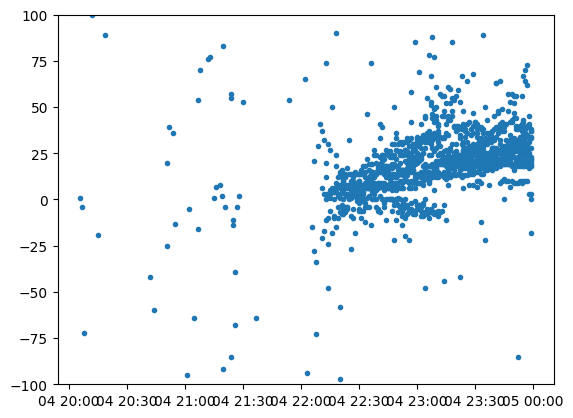

In [ ]:
plt.plot(df['minute'], df['best_lag'], '.')
plt.ylim(-100,100)
plt.plot()


,svid,cons,minute,s4A,s4B,elev_A,elev_B,azim_A,azim_B,r1loc,r2loc,corr_norm,lag_norm,max_corr,best_lag,time_delay,distance (km),velocity (km/s)
0,2,GAL,2022-10-04 22:22:00,0.248260,0.246203,32.000000,32.00000,306.131250,306.547917,"[-7.2121882, -35.90611, 0.55649865]","[-7.212652, -35.9073, 0.5425475]","[0.00023601625850355374, 0.0015509639844519247...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.724705,6,0.30,0.141599,0.471995
1,2,GAL,2022-10-04 22:23:00,0.258300,0.282083,32.000000,32.00000,307.000000,307.000000,"[-7.2121882, -35.906105, 0.5563686]","[-7.212652, -35.907295, 0.542493]","[-1.7930009852308093e-05, -3.5860019704616186e...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.645983,6,0.30,0.141591,0.471971
2,2,GAL,2022-10-04 22:24:00,0.356450,0.339789,31.639413,31.48847,307.360587,307.511530,"[-7.2121873, -35.906105, 0.55611974]","[-7.212652, -35.907295, 0.54223895]","[-0.0006721788745185038, -0.001344357749037007...","[-476, -475, -474, -473, -472, -471, -470, -46...",0.811655,6,0.30,0.141626,0.472088
3,2,GAL,2022-10-04 22:25:00,0.316135,0.314274,31.000000,31.00000,308.000000,308.000000,"[-7.2121873, -35.906105, 0.55578876]","[-7.212652, -35.907295, 0.5419835]","[4.9965221128560714e-05, 9.993044225712143e-05...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.744665,6,0.30,0.141619,0.472063
4,2,GAL,2022-10-04 22:26:00,0.345028,0.325862,31.000000,31.00000,308.000000,308.481250,"[-7.2121882, -35.906105, 0.5553776]","[-7.212654, -35.907295, 0.5417687]","[-0.0001734960252106696, -0.000346992050421339...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.686357,7,0.35,0.141635,0.404670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1530,136,SBS,2022-10-04 23:37:00,0.332755,0.340081,42.000000,42.00000,82.000000,82.000000,"[-7.2122126, -35.906174, 0.55261135]","[-7.2126813, -35.907364, 0.53728354]","[-0.0002986801244202465, -0.000597360248840493...","[-949, -948, -947, -946, -945, -944, -943, -94...",0.862867,18,0.90,0.141914,0.157683
1531,136,SBS,2022-10-04 23:38:00,0.311478,0.274253,42.000000,42.00000,82.000000,82.000000,"[-7.2122173, -35.906174, 0.5526083]","[-7.2126837, -35.907364, 0.5371062]","[-0.001273931181367274, -0.002547862362734548,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.798184,18,0.90,0.141864,0.157626
1532,136,SBS,2022-10-04 23:39:00,0.263936,0.258914,42.000000,42.00000,82.000000,82.000000,"[-7.2122197, -35.906174, 0.55342394]","[-7.2126837, -35.907364, 0.53767467]","[-0.000405569010462156, -0.000811138020924312,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.765527,16,0.80,0.141787,0.177234
1533,136,SBS,2022-10-04 23:40:00,0.212937,0.179114,42.000000,42.00000,82.000000,82.000000,"[-7.2122235, -35.906166, 0.55444056]","[-7.2126865, -35.90736, 0.5384905]","[-0.0017825553229625494, -0.003565110645925099...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.589147,23,1.15,0.142438,0.123859


[]

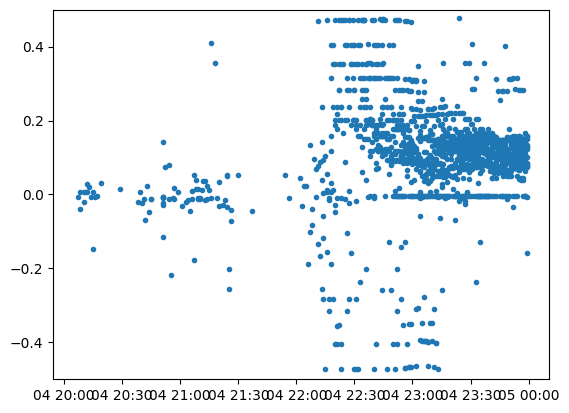

In [17]:
#find velocity

df['velocity (km/s)'] = df['distance (km)']/df['time_delay']
#print(f'{V} km/s')
display(df)

sat = df[df['svid'] == 10] #& (df['cons'] == 3)

# plt.figure(figsize=(10,5))
# plt.plot(sat['minute'], sat['velocity (km/s)'])

# plt.xlabel("Time (minute)")
# plt.ylabel("Velocity (km/s)")
# plt.title("Scintillation Drift Velocity Over Time")
# plt.xticks(rotation=45)
# plt.show()

plt.plot(df['minute'], df['velocity (km/s)'], '.')
plt.ylim(-0.5,0.5)

plt.plot()


23


,svid,cons,minute,s4A,s4B,elev_A,elev_B,azim_A,azim_B,r1loc,r2loc,corr_norm,lag_norm,max_corr,best_lag,time_delay,distance (km),velocity (km/s)
293,10,GPS,2022-10-04 20:19:00,0.070515,0.201961,40.000000,40.000000,309.000000,309.000000,"[-7.212241, -35.906075, 0.5615411]","[-7.2126865, -35.907265, 0.54672724]","[0.0013887706634087742, 0.0027775413268175484,...","[-719, -718, -717, -716, -715, -714, -713, -71...",0.271832,89,4.45,0.140938,0.031672
294,10,GPS,2022-10-04 20:51:00,0.215122,0.100693,49.545833,50.000000,289.908333,290.000000,"[-7.212226, -35.906067, 0.5568761]","[-7.2126875, -35.90726, 0.5404531]","[-0.0005985657184009801, -0.001197131436801960...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.349516,20,1.00,0.142457,0.142457
295,10,GPS,2022-10-04 22:53:00,0.218115,0.237948,40.000000,40.000000,198.286111,198.000000,"[-7.212177, -35.906113, 0.54839563]","[-7.212663, -35.907295, 0.5354846]","[-0.0009328340825836345, -0.002235718049167388...","[-719, -718, -717, -716, -715, -714, -713, -71...",0.735514,13,0.65,0.141726,0.218040
296,10,GPS,2022-10-04 22:54:00,0.469104,0.492914,40.000000,39.419444,198.000000,197.419444,"[-7.2121773, -35.906116, 0.54801375]","[-7.2126665, -35.907295, 0.53490907]","[-0.00489790169609801, -0.00979580339219602, -...","[-719, -718, -717, -716, -715, -714, -713, -71...",0.881705,21,1.05,0.141507,0.134768
297,10,GPS,2022-10-04 22:55:00,1.021276,1.040916,39.352778,39.000000,197.352778,197.000000,"[-7.212177, -35.906116, 0.54756856]","[-7.2126656, -35.907295, 0.5346412]","[0.00030109690524313234, 0.0006632441545513322...","[-719, -718, -717, -716, -715, -714, -713, -71...",0.904379,20,1.00,0.141454,0.141454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,10,GPS,2022-10-04 23:55:00,0.676954,0.515771,27.286458,27.419792,169.000000,169.000000,"[-7.212226, -35.906155, 0.55914867]","[-7.212689, -35.90734, 0.5431365]","[0.002135045202608944, 0.004270090405217888, 0...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.747849,67,3.35,0.141434,0.042219
358,10,GPS,2022-10-04 23:56:00,0.910103,0.908810,27.000000,27.000000,169.000000,169.000000,"[-7.2122307, -35.90616, 0.5591218]","[-7.2126927, -35.90734, 0.5427405]","[-5.1147772546745045e-05, -0.00010229554509349...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.673341,70,3.50,0.141059,0.040302
359,10,GPS,2022-10-04 23:57:00,0.735396,1.019282,27.000000,27.000000,168.353125,168.453125,"[-7.2122307, -35.90616, 0.56004244]","[-7.212695, -35.90734, 0.54295677]","[-0.0016195280442521797, -0.003239056088504359...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.359487,73,3.65,0.141246,0.038698
360,10,GPS,2022-10-04 23:58:00,1.028784,1.262397,27.000000,27.000000,168.000000,168.000000,"[-7.212229, -35.906155, 0.560359]","[-7.2126937, -35.90734, 0.543467]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-959, -958, -957, -956, -955, -954, -953, -95...",NaN,-959,-47.95,0.141571,-0.002952


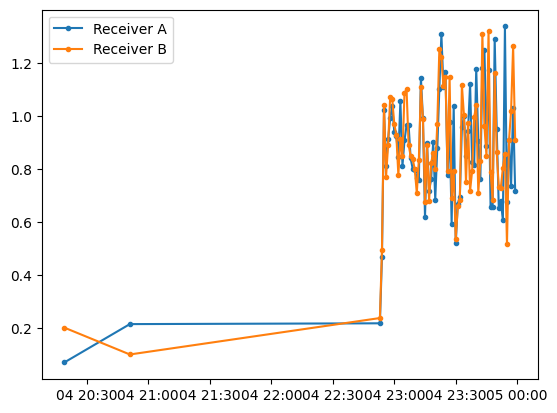

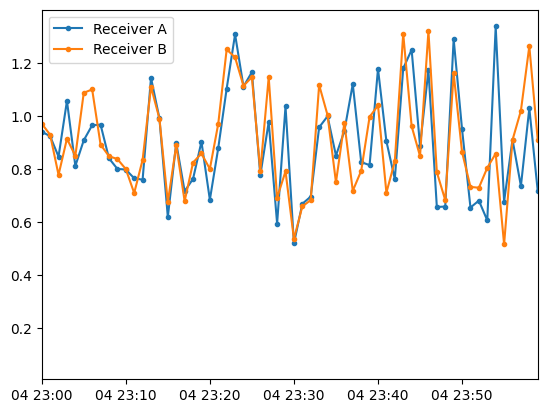

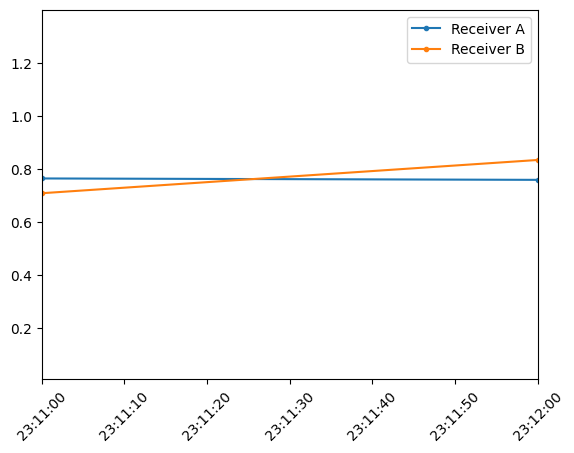

In [4]:
#plotting
#sat should be in config
sat = df[df['svid'] == 10] #& (df['cons'] == 3)
print(sat["max_corr"].isna().sum())
#find event
display(sat)

plt.plot(sat["minute"], sat["s4A"],'.-', label="Receiver A")
plt.plot(sat["minute"], sat["s4B"],'.-', label="Receiver B")
# plt.xlim(
#        pd.Timestamp("2022-10-04 23:00:00"),
#       pd.Timestamp("2022-10-04 23:01:00")
#     )
plt.legend()
plt.show()

#graph showing scintiallltion at 23:00 to 23:30
plt.plot(sat["minute"], sat["s4A"],'.-', label="Receiver A")
plt.plot(sat["minute"], sat["s4B"],'.-', label="Receiver B")
plt.xlim(
       pd.Timestamp("2022-10-04 23:00:00"),
      pd.Timestamp("2022-10-04 23:59:00")
    )
plt.legend()
plt.show()


#chose a single minute #minute 11
plt.plot(sat["minute"], sat["s4A"],'.-', label="Receiver A")
plt.plot(sat["minute"], sat["s4B"],'.-', label="Receiver B")
plt.xlim(
       pd.Timestamp("2022-10-04 23:11:00"),
      pd.Timestamp("2022-10-04 23:12:00")
    )
plt.legend()
plt.xticks(rotation=45)
plt.show()





0.9215629355222147
36
1.8
2022-10-04 23:11:00


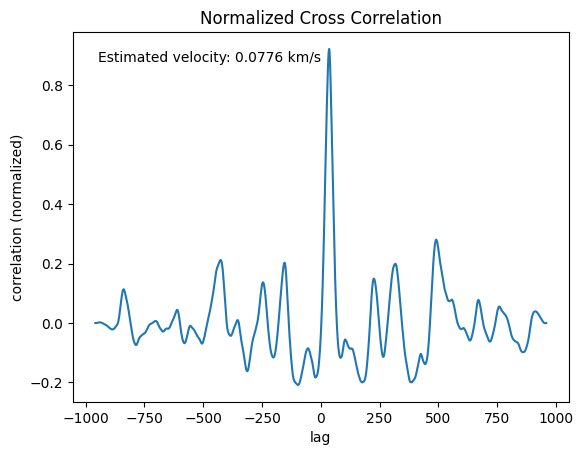

In [5]:

event = sat.iloc[20]

print(event['max_corr'])
print(event['best_lag'])
print(event['time_delay'])
print(event['minute'])

plt.plot(event['lag_norm'], event['corr_norm'])
plt.xlabel('lag')
plt.ylabel('correlation (normalized)')
plt.title('Normalized Cross Correlation')

V = event['velocity (km/s)']
plt.text(
    0.05, 0.95,
    f"Estimated velocity: {V:.4f} km/s",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.show()

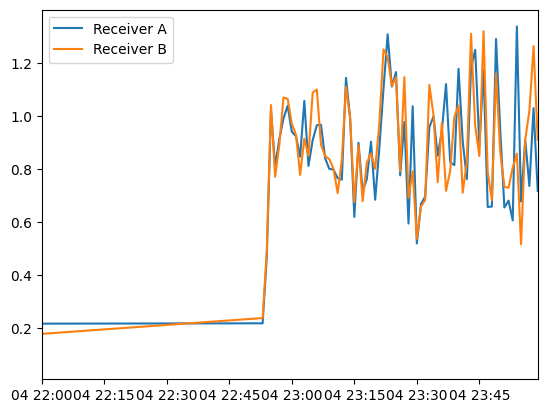

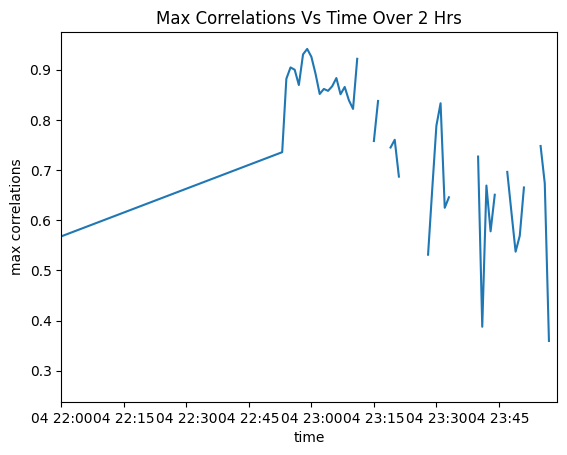

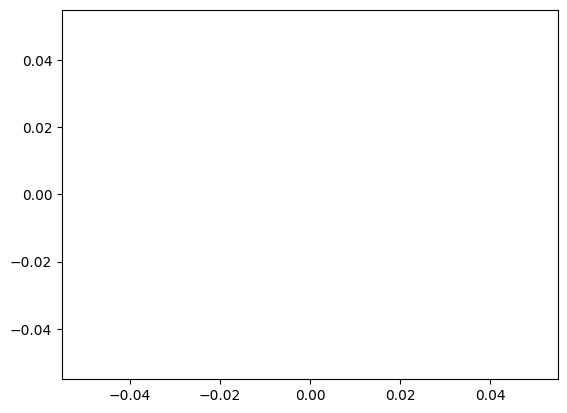

,svid,cons,minute,s4A,s4B,elev_A,elev_B,azim_A,azim_B,r1loc,r2loc,corr_norm,lag_norm,max_corr,best_lag,time_delay,distance (km),velocity (km/s)
314,10,GPS,2022-10-04 23:12:00,0.759342,0.834275,35.000000,35.717733,188.000000,188.717733,"[-7.2122016, -35.906155, 0.5450411]","[-7.21269, -35.90732, 0.52971196]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-952, -951, -950, -949, -948, -947, -946, -94...",NaN,-952,-47.60,0.140313,-0.002948
315,10,GPS,2022-10-04 23:13:00,1.143225,1.109097,35.000000,35.000000,187.952083,188.000000,"[-7.2122016, -35.906155, 0.5447846]","[-7.212696, -35.907333, 0.53077585]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-959, -958, -957, -956, -955, -954, -953, -95...",NaN,-959,-47.95,0.141813,-0.002958
316,10,GPS,2022-10-04 23:14:00,0.990686,0.989440,35.000000,35.000000,187.000000,187.749471,"[-7.2122016, -35.90616, 0.5447755]","[-7.212701, -35.907337, 0.53158206]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-945, -944, -943, -942, -941, -940, -939, -93...",NaN,-945,-47.25,0.141957,-0.003004
319,10,GPS,2022-10-04 23:17:00,0.715997,0.678544,35.000000,34.000000,186.000000,186.000000,"[-7.212207, -35.906162, 0.54445475]","[-7.212712, -35.907345, 0.53126776]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-959, -958, -957, -956, -955, -954, -953, -95...",NaN,-959,-47.95,0.142869,-0.002980
320,10,GPS,2022-10-04 23:18:00,0.762295,0.823770,34.086458,34.000000,185.086458,185.819792,"[-7.212208, -35.906166, 0.5444046]","[-7.2127194, -35.90734, 0.5307569]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-959, -958, -957, -956, -955, -954, -953, -95...",NaN,-959,-47.95,0.142181,-0.002965
324,10,GPS,2022-10-04 23:22:00,1.102592,1.250370,33.218750,33.886458,183.218750,183.886458,"[-7.2122164, -35.90617, 0.5437377]","[-7.212722, -35.907352, 0.52927816]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-959, -958, -957, -956, -955, -954, -953, -95...",NaN,-959,-47.95,0.142685,-0.002976
325,10,GPS,2022-10-04 23:23:00,1.307065,1.219940,33.000000,33.000000,183.000000,183.000000,"[-7.2122188, -35.90617, 0.54314977]","[-7.212722, -35.907356, 0.52925545]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-957, -956, -955, -954, -953, -952, -951, -95...",NaN,-957,-47.85,0.142862,-0.002986
327,10,GPS,2022-10-04 23:25:00,1.164589,1.145315,33.000000,33.000000,183.000000,182.000000,"[-7.212224, -35.90617, 0.5431251]","[-7.2127132, -35.907364, 0.52690136]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-959, -958, -957, -956, -955, -954, -953, -95...",NaN,-959,-47.95,0.143212,-0.002987
328,10,GPS,2022-10-04 23:26:00,0.775452,0.791501,32.352083,32.953125,182.352083,181.953125,"[-7.212224, -35.906174, 0.5434234]","[-7.2127085, -35.907364, 0.52632576]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-959, -958, -957, -956, -955, -954, -953, -95...",NaN,-959,-47.95,0.142788,-0.002978
329,10,GPS,2022-10-04 23:27:00,0.976931,1.145599,32.000000,32.000000,182.000000,181.000000,"[-7.212224, -35.906174, 0.5433349]","[-7.2127085, -35.907364, 0.52677256]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-959, -958, -957, -956, -955, -954, -953, -95...",NaN,-959,-47.95,0.142725,-0.002977


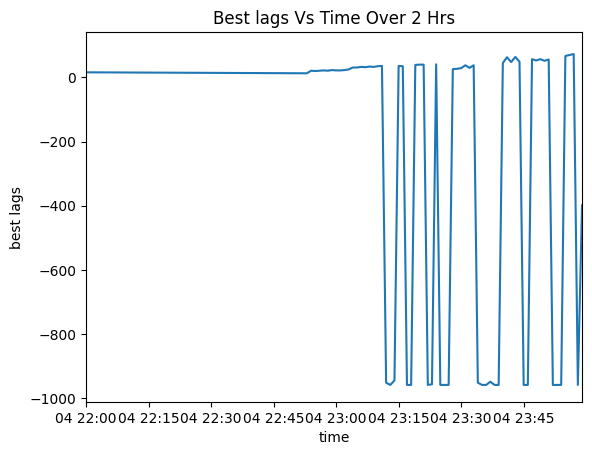

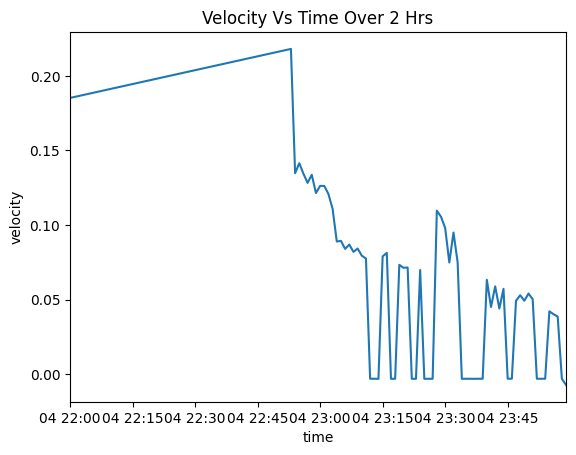

In [11]:

sat = df[df['svid'] == 10]

#graph showing scintiallltion over 2 hrs at 22:00 to 23:59
plt.plot(sat["minute"], sat["s4A"], label="Receiver A")
plt.plot(sat["minute"], sat["s4B"], label="Receiver B")
plt.xlim(
       pd.Timestamp("2022-10-04 22:00:00"),
      pd.Timestamp("2022-10-04 23:59:00")
    )
plt.legend()
plt.show()

plt.plot(sat['minute'], sat['max_corr'])
plt.xlabel('time')
plt.ylabel('max correlations')
plt.title('Max Correlations Vs Time Over 2 Hrs')
plt.xlim(
       pd.Timestamp("2022-10-04 22:00:00"),
      pd.Timestamp("2022-10-04 23:59:00")
    )
plt.show()

wrong_sats= sat[sat['best_lag'] < -900]
wrong_sat1 = wrong_sats.iloc[0]
plt.plot(wrong_sat1['lag_norm'],wrong_sat1['corr_norm'])
plt.show()
display(wrong_sats)

plt.plot(sat['minute'], sat['best_lag'])
plt.xlabel('time')
plt.ylabel('best lags')
plt.title('Best lags Vs Time Over 2 Hrs')
plt.xlim(
       pd.Timestamp("2022-10-04 22:00:00"),
      pd.Timestamp("2022-10-04 23:59:00")
    )
plt.show()

plt.plot(sat['minute'], sat['velocity (km/s)'])
plt.xlabel('time')
plt.ylabel('velocity')
plt.title('Velocity Vs Time Over 2 Hrs')
plt.xlim(
       pd.Timestamp("2022-10-04 22:00:00"),
      pd.Timestamp("2022-10-04 23:59:00")
    )
plt.show()




#max corr could have blank values when normalizing bc dividing by 0
#or more likely when data is filtered out in the time points bc the s4 value didnt pass the threshold

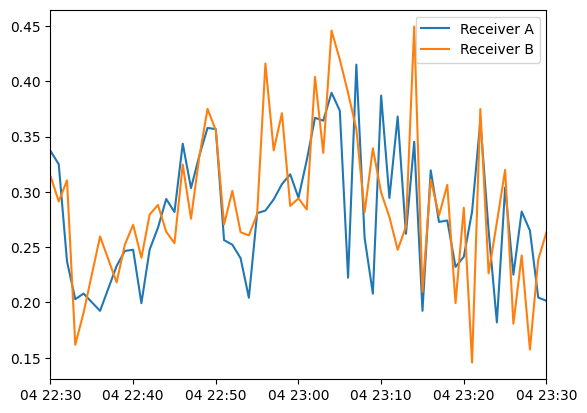

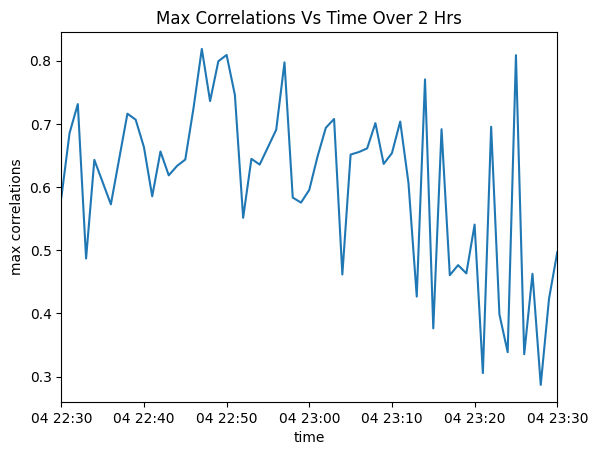

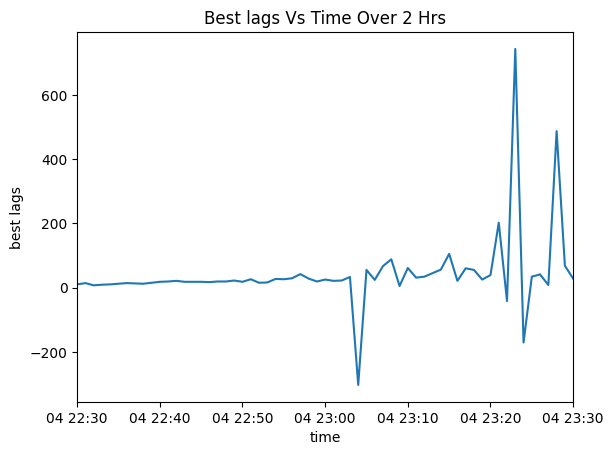

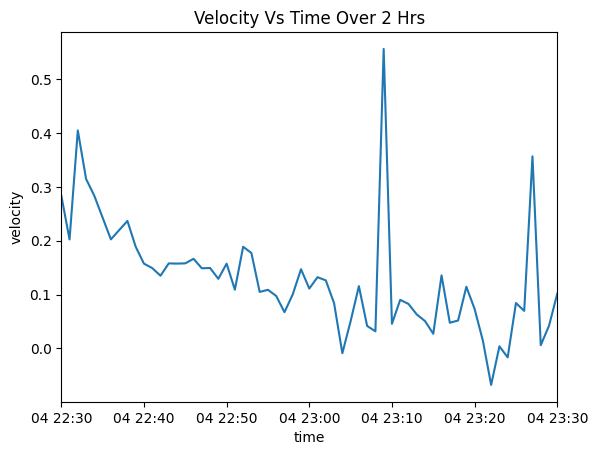

In [7]:
#sat 10 has a prob with max cor having nan values lets change it

sat = df[df['svid'] == 2] #& (df['cons'] == 3)



#graph showing scintiallltion over 2 hrs at 22:00 to 23:59
plt.plot(sat["minute"], sat["s4A"], label="Receiver A")
plt.plot(sat["minute"], sat["s4B"], label="Receiver B")
plt.xlim(
       pd.Timestamp("2022-10-04 22:30:00"),
      pd.Timestamp("2022-10-04 23:30:00")
    )
plt.legend()
plt.show()

plt.plot(sat['minute'], sat['max_corr'])
plt.xlabel('time')
plt.ylabel('max correlations')
plt.title('Max Correlations Vs Time Over 2 Hrs')
plt.xlim(
       pd.Timestamp("2022-10-04 22:30:00"),
      pd.Timestamp("2022-10-04 23:30:00")
    )
plt.show()

plt.plot(sat['minute'], sat['best_lag'])
plt.xlabel('time')
plt.ylabel('best lags')
plt.title('Best lags Vs Time Over 2 Hrs')
plt.xlim(
       pd.Timestamp("2022-10-04 22:30:00"),
      pd.Timestamp("2022-10-04 23:30:00")
    )
plt.show()

plt.plot(sat['minute'], sat['velocity (km/s)'])
plt.xlabel('time')
plt.ylabel('velocity')
plt.title('Velocity Vs Time Over 2 Hrs')
plt.xlim(
       pd.Timestamp("2022-10-04 22:30:00"),
      pd.Timestamp("2022-10-04 23:30:00")
    )
plt.show()


#max corr could have blank values when normalizing bc dividing by 0
#or more likely when data is filtered out in the time points bc the s4 value didnt pass the threshold

In [8]:
print(sat["max_corr"].isna().sum())
print(sat["max_corr"].describe())

0
count    67.000000
mean      0.616842
std       0.130386
min       0.286936
25%       0.562083
50%       0.644690
75%       0.702479
max       0.818651
Name: max_corr, dtype: float64
